# Chapter 11 — Backtesting III: Walk-Forward and Statistical Validation

This is the chapter that closes the deflation arc. Ch8 produced an in-sample Sharpe of **+2.08**. Ch9 fixed the mechanics and brought it to **+0.80**. Ch10 fixed bias from look-ahead and snooping, but every Sharpe Ch10 quoted was still computed on the same data used to choose the strategy's parameters. Ch11 introduces the discipline of separating those two activities — *parameter selection* and *performance estimation*.

The job here is the simplest validation question that exists: **does the strategy survive on data the strategy has never seen?**

Three flavors of "did it work out-of-sample?":

1. **Train/test split** — the cheapest validation. Hold out the last 30% of sessions, fit on the first 70%, evaluate the trained parameter on the held-out portion. Single comparison; quick to compute; honest if you do it once.
2. **Walk-forward optimization** — refit monthly on a 3-month trailing window; concatenate the OOS PnL across all rolls. Yields a continuously-OOS PnL series and a sequence of parameter choices whose stability you can inspect.
3. **Bootstrap CI on OOS PnL** — the OOS Sharpe is itself noisy. The CI is what tells you whether the strategy is statistically distinguishable from random.

The chapter's punchline number — the one to carry into Ch12 and beyond — is the walk-forward concatenated OOS Sharpe with its bootstrap CI. The honest answer for this strategy on this data: **+0.88, 95% CI ≈ (−1.6, +3.5)**. Positive point estimate; CI comfortably includes zero.

## Three things this chapter covers

1. **The IS/OOS gap is the real signal-to-noise.** Section §1. A strategy with IS Sharpe 2.0 and OOS Sharpe 0.6 is real but weak; a strategy with IS Sharpe 2.0 and OOS Sharpe 0.0 was a curve fit. The two look identical at the IS stage; only OOS distinguishes them.
2. **Walk-forward gives you adaptive evaluation.** Section §3. Parameters refit window-by-window; you observe the *sequence* of choices as well as the OOS performance. Parameter stability is its own diagnostic.
3. **A point Sharpe without a CI is incomplete.** Section §4. Even an OOS point Sharpe is a noisy estimator. Block-bootstrapping the OOS PnL — at the trade level *and* at the daily level — gives you both the lower bound (the smallest plausible truth) and the upper bound (the strategy isn't *that* good either).

> **Definition — in-sample (IS).** Performance computed on the exact data used to choose the strategy's parameters. An *upper bound* on what the strategy can really do, never the strategy's actual edge. Always optimistic.
>
> **Definition — out-of-sample (OOS).** Performance computed on data the strategy has never seen — neither during parameter selection nor during any "this looks reasonable" decision. Slightly less optimistic than IS by construction; tracking truth more closely.
>
> **Definition — train/test split.** A single partition of the dataset into a `train` portion (used for parameter selection) and a `test` portion (held out for OOS evaluation). The simplest validation; honest if you only evaluate on the test set *once*.
>
> **Definition — walk-forward optimization.** Repeated train/test splits in chronological sliding-window form. At each step, refit on a trailing window, evaluate on the next window, slide forward. Concatenate OOS evaluations into a single series.
>
> **Definition — deflation factor.** The ratio OOS Sharpe / IS Sharpe. A typical retail strategy deflates to 0.3-0.7. Above 0.7 is suspicious (suggests not enough genuine OOS, or accidental information leakage). At 0 means the IS was noise.

## §1 — The IS/OOS gap is the real signal-to-noise ratio

Every IS Sharpe is, mechanically, an *upper bound* on the strategy's true expected performance. The mechanism is parameter selection: you sweep, you pick the best. The "best" is the maximum over noisy estimates and exceeds any single estimate's mean by construction.

The OOS Sharpe is the lower-variance estimator of truth. Truth itself — what the strategy will actually produce on data not yet observed — sits between IS and OOS in expectation, closer to OOS than to IS.

Two numerical examples to anchor intuition. Both refer to a hypothetical strategy with a "true" Sharpe of 0.5:

- IS = 2.0, OOS = 0.6. Plausible; the IS picks up genuine signal plus some snooping inflation; OOS captures the signal without the inflation. **Real-but-weak**.
- IS = 2.0, OOS = 0.0. Also plausible; the IS was almost entirely noise plus snooping; OOS realized truth = 0. **Curve fit**.

The difference is the deflation factor (OOS / IS):

- 0.30 in the first case (real-but-weak)
- 0.00 in the second (curve fit)

Without OOS, you literally cannot distinguish these two strategies. *Every* serious quant pipeline runs OOS validation; *no* serious quant pipeline reports IS Sharpe as the strategy's edge.

## §2 — Train/test split

The simplest possible validation. We hold out the last 30% of sessions as the test window — 76 sessions, roughly 4 months. We sweep `k_σ` across 21 values on the first 70% (175 sessions), pick the in-sample best, and apply it *unchanged* to the held-out portion.

> **Definition — holdout set.** Synonymous with the test set in a train/test split. The portion of the data the strategy and its parameters are *never* fit to.
>
> **Operational rule:** evaluate on the holdout exactly once. Iterate on the holdout — re-tune after seeing OOS performance — and you have effectively re-merged train and test, with all the snooping that implies.

### Results

| Quantity                          | Value   |
| --------------------------------- | ------- |
| Best train k_σ                    | 1.40    |
| IS Sharpe (train, 175 sessions)   | **+1.65** |
| OOS Sharpe (test, 76 sessions)    | **+0.46** |
| Deflation factor (OOS / IS)       | 0.28    |

**The held-out 30% retained roughly one-quarter of the in-sample Sharpe.** That deflation factor of 0.28 sits at the severe end of the typical 0.3-0.7 range — the strategy was meaningfully fit to the train portion. The OOS Sharpe of +0.46 is below the 0.5 retail-tradable threshold, but only just.

### A subtle finding

Ch10 §4's *full-sample* sweep best was `k_σ = 0.50` with Sharpe +1.86. Here, on the train portion alone, the best is `k_σ = 1.40`. **The "best" parameter is itself unstable across windows.**

That instability is informative. Snooping bias produces unstable choices, not just inflated Sharpes. If the optimizer picks `k_σ = 0.50` on the full sample but `k_σ = 1.40` on the first 70% of sessions, the parameter is not *measuring something stable about the strategy* — it is *fitting noise specific to each window*. Real edges produce stable optimizers.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CACHE = Path("../06-bridge-to-intraday/data")
qqq = pd.read_parquet(CACHE / "qqq_1min.parquet")
# Convert UTC index to NY time so 9:30/16:00 cuts match the cash session.
qqq.index = pd.to_datetime(qqq.index, utc=True).tz_convert("America/New_York")
qqq["minute_of_day"] = qqq.index.hour * 60 + qqq.index.minute
RTH_OPEN, RTH_CLOSE = 9*60+30, 16*60
# Boolean mask keeps only rows inside the regular trading hours window.
rth = qqq[(qqq["minute_of_day"] >= RTH_OPEN) & (qqq["minute_of_day"] < RTH_CLOSE)].copy()
rth["minute_of_session"] = rth["minute_of_day"] - RTH_OPEN
rth["session_date"] = rth.index.normalize()
# 1-minute log return; .shift(1) pulls the prior minute's close.
rth["log_ret"] = np.log(rth["close"] / rth["close"].shift(1))
# First bar of each session bridges yesterday's close → today's open: blank it.
sf = rth.groupby("session_date").head(1).index
rth.loc[sf, "log_ret"] = np.nan

N, K = 1, 3
ENTRY_START, ENTRY_END = 360, 389

# Per-session "prior moves": every N-minute log return inside the entry window.
# These are the points whose σ becomes the threshold scale used by the strategy.
priors_by_session = {}
for date, day in rth.groupby("session_date"):
    day = day.sort_index().reset_index(drop=True)
    pts = []
    for i in range(N, len(day)):
        # Only collect priors at minutes where the strategy could legally enter.
        if ENTRY_START <= day.loc[i, "minute_of_session"] < ENTRY_END - K:
            pts.append(np.log(day.loc[i, "close"] / day.loc[i - N, "close"]))
    priors_by_session[date] = np.array(pts)
sessions_all = sorted(priors_by_session.keys())
print(f"{len(sessions_all)} sessions  ·  {sessions_all[0].date()} → {sessions_all[-1].date()}")


251 sessions  ·  2025-05-08 → 2026-05-07


In [2]:
def sigma_from_sessions(sessions_iter):
    # Pool prior-move samples from the requested sessions and take their std.
    # σ here is the in-sample scale that calibrates the entry threshold.
    pts = [priors_by_session[s] for s in sessions_iter if s in priors_by_session]
    if not pts: return None
    arr = np.concatenate(pts)
    return arr.std() if len(arr) > 0 else None

def event_driven_backtest(rth_df, sessions_set, k_sigma, sigma):
    """Run the single-position event-driven backtest restricted to sessions_set,
    with threshold = k_sigma * sigma (sigma is from a separate point-in-time set)."""
    threshold = k_sigma * sigma
    # Restrict bars to the OOS (or IS) sessions — no leakage across the split.
    sub = rth_df[rth_df["session_date"].isin(sessions_set)]
    trades = []
    for date, day in sub.groupby("session_date"):
        day = day.sort_index().reset_index(drop=True)
        in_pos, entry_i, entry_px = 0, None, None
        for i in range(len(day)):
            mos   = day.loc[i, "minute_of_session"]
            close = day.loc[i, "close"]
            # Time-stop: K minutes after entry, exit at next bar's open.
            if in_pos != 0 and (i - entry_i) >= K:
                exit_i  = min(i + 1, len(day) - 1)
                exit_px = day.loc[exit_i, "open"]
                trades.append({"date": date, "side": in_pos,
                               "pnl_log": in_pos * np.log(exit_px / entry_px)})
                in_pos, entry_i, entry_px = 0, None, None
            # Entry trigger: |prior N-min move| exceeds k·σ → fade the move.
            if in_pos == 0 and ENTRY_START <= mos < ENTRY_END - K and i >= N:
                prior_N = np.log(close / day.loc[i - N, "close"])
                if abs(prior_N) > threshold:
                    sig = -1 if prior_N > 0 else +1
                    # Fill at the *next* bar's open to avoid look-ahead on close.
                    entry_i_next = min(i + 1, len(day) - 1)
                    in_pos, entry_i, entry_px = sig, i, day.loc[entry_i_next, "open"]
        # Force-close any open position at the session's last close.
        if in_pos != 0:
            close_last = day.loc[len(day) - 1, "close"]
            trades.append({"date": date, "side": in_pos,
                           "pnl_log": in_pos * np.log(close_last / entry_px)})
    return pd.DataFrame(trades)

def sharpe(tr):
    if len(tr) < 2: return float("nan")
    mu, sd = tr["pnl_log"].mean(), tr["pnl_log"].std()
    if sd == 0: return float("nan")
    # Annualization factor: 252 × (trades per session) so per-trade Sharpe scales
    # to a comparable yearly figure regardless of how often the strategy fires.
    s = tr["date"].nunique()
    return (mu / sd) * np.sqrt(252 * len(tr) / max(s, 1))


In [3]:
# Single 70/30 chronological split — the simplest IS/OOS partition.
split = int(0.7 * len(sessions_all))
train_sessions = set(sessions_all[:split])
test_sessions  = set(sessions_all[split:])
# σ is fit on TRAIN only, then frozen for the OOS test (point-in-time discipline).
train_sigma = sigma_from_sessions(train_sessions)

print(f"Train: {len(train_sessions)} sessions  σ={train_sigma:.6f}")
print(f"Test:  {len(test_sessions)} sessions")

# Sweep k_sigma on train; pick best
sweep_rows = []
for k_sigma in np.linspace(0.5, 2.5, 21):
    # Same σ (train-fit) is used for both runs — only the session set changes.
    tr_train = event_driven_backtest(rth, train_sessions, k_sigma, train_sigma)
    tr_test  = event_driven_backtest(rth, test_sessions,  k_sigma, train_sigma)
    sweep_rows.append({
        "k_sigma": round(k_sigma, 2),
        "is_sharpe":  round(sharpe(tr_train), 3),
        "oos_sharpe": round(sharpe(tr_test),  3),
        "is_n":  len(tr_train),
        "oos_n": len(tr_test),
    })
sweep_tt = pd.DataFrame(sweep_rows)
# Pick the k with highest IS Sharpe — the canonical "optimize on train" rule.
best_idx = sweep_tt["is_sharpe"].idxmax()
best = sweep_tt.iloc[best_idx]
print(f"\nBest train k_σ: {best['k_sigma']:.2f}")
print(f"  IS Sharpe:  {best['is_sharpe']:+.3f}")
print(f"  OOS Sharpe: {best['oos_sharpe']:+.3f}")
# Deflation factor < 1 quantifies how much of the IS edge survives OOS.
print(f"  Deflation factor (OOS / IS): {best['oos_sharpe'] / best['is_sharpe']:.2f}")
sweep_tt


Train: 175 sessions  σ=0.000349
Test:  76 sessions



Best train k_σ: 1.40
  IS Sharpe:  +1.652
  OOS Sharpe: +0.460
  Deflation factor (OOS / IS): 0.28


,k_sigma,is_sharpe,oos_sharpe,is_n,oos_n
0,0.5,0.545,3.273,1079,526
1,0.6,0.830,2.903,969,490
2,0.7,1.148,2.338,865,454
3,0.8,1.160,3.336,784,416
4,0.9,0.697,2.263,695,382
5,1.0,0.750,1.285,610,353
6,1.1,1.290,1.275,546,317
7,1.2,1.496,-0.126,488,291
8,1.3,1.144,-0.517,436,254
9,1.4,1.652,0.460,379,235


## §3 — Walk-forward optimization

Train/test split is one comparison. Walk-forward is many — and crucially, it lets the strategy *adapt* between windows. The procedure:

1. Slide a 3-month training window along the data, advancing one month at a time.
2. At each step, refit the strategy parameter (sweep `k_σ` ∈ [0.5, 2.5] in 21 steps; pick IS best) on the trailing 3 months. Refit σ from the same 3 months.
3. Evaluate the refit strategy on the *next* month, using its own σ (point-in-time-clean).
4. Concatenate the OOS trades across all walk-forward steps; compute aggregate metrics on the combined ledger.

The output is a continuously-OOS PnL series and a sequence of parameter choices.

### What the procedure shows

10 effective walk-forward windows after the 3-month warmup. Per-window summary:

| Month   | k_σ best | IS Sharpe | OOS trades | OOS Sharpe |
| ------- | -------- | --------- | ---------- | ---------- |
| 2025-08 | 1.6      | +3.34     |  19        | −0.73      |
| 2025-09 | 1.5      | +5.22     |  42        | +2.49      |
| 2025-10 | 2.5      | +6.47     |  36        | −1.36      |
| 2025-11 | 1.2      | +1.37     | 104        | −0.59      |
| 2025-12 | 0.7      | +1.59     |  77        | +1.36      |
| 2026-01 | 0.7      | +1.35     |  92        | −0.41      |
| 2026-02 | 0.7      | +2.54     | 116        | +5.62      |
| 2026-03 | 1.8      | +4.22     |  64        | +4.53      |
| 2026-04 | 2.1      | +5.36     |   8        | −17.6      |
| 2026-05 | 0.7      | +3.05     |  17        | +2.97      |

**Walk-forward concatenated OOS Sharpe: +0.88** (575 trades over 148 sessions).

### Reading the table

Three observations.

**1. Concatenate the trade ledger; do not average per-month Sharpes.** The 10 monthly Sharpes range from −17.6 (Apr) to +5.6 (Feb); their simple mean is dominated by the two anomalously bad windows. What the strategy would have *produced* in real trading is the trade-weighted concat number (+0.88), where 116 February trades count more than 8 April trades.

The April number deserves a flag. The optimizer picked `k_σ = 2.1` on March's training window, which is restrictive; only 8 trades fired on the OOS month; one or two big losses dominate the Sharpe. **Small monthly samples produce noisy monthly Sharpes** — another reason not to equally-weight per-month aggregates.

**2. Walk-forward (+0.88) > train/test (+0.46) on this data.** Counter-intuitive at first — the more elaborate procedure looks better. The reason is regime adaptation: the per-month refit picks up on volatility shifts that the single-fixed-parameter train/test split cannot. When the market regime in late 2025 shifts (closing-minute volatility increases), walk-forward raises `k_σ` mid-stream; train/test cannot.

That said, walk-forward's adaptiveness *also* gives the optimizer 10 chances to fit noise instead of one. Per-window snooping is a real bias — see §5. The +0.88 number is the OOS aggregate of 10 per-window IS-best choices, not the OOS performance of a single fixed parameter; it inherits some optimization variance.

**3. Parameter stability is poor.** The selected `k_σ` ranges from 0.7 to 2.5 across the 10 windows — a 3.5× swing. The mode is 0.7 (4 of 10 windows). Standard deviation across windows is 0.66.

A stable strategy should produce a stable optimizer. If `k_σ` is genuinely the right knob to tune, repeated refits should pick similar values — perhaps drifting slowly with regime, but not jumping by a factor of 3 between months. Here it jumps. **The in-sample best is mostly noise.**

In [4]:
# Map each session date to its calendar month period — the unit for refits.
sessions_per_month = pd.Series(
    [pd.Timestamp(s).tz_localize(None).to_period("M") for s in sessions_all],
    index=sessions_all)
unique_months = sorted(sessions_per_month.unique())

oos_trades = []
parameter_log = []

# Rolling 3-month-train → 1-month-test walk-forward. Each fold refits k_σ.
for i, m in enumerate(unique_months):
    if i < 3:                                # 3-month warmup
        continue
    # Anchored-rolling train window: the 3 months immediately before month m.
    train_months = set(unique_months[i-3:i])
    train_set = {s for s in sessions_all if sessions_per_month[s] in train_months}
    test_set  = {s for s in sessions_all if sessions_per_month[s] == m}
    if not train_set or not test_set: continue
    # σ refit each fold on TRAIN only — never sees OOS data.
    train_sig = sigma_from_sessions(train_set)
    if train_sig is None or train_sig == 0: continue
    # In-sample sweep
    best_k_w, best_s = None, -np.inf
    for k_sigma in np.linspace(0.5, 2.5, 21):
        tr_w = event_driven_backtest(rth, train_set, k_sigma, train_sig)
        s = sharpe(tr_w)
        if not np.isnan(s) and s > best_s:
            best_s, best_k_w = s, k_sigma
    if best_k_w is None: continue
    # OOS — apply best_k_w with train_sig (point-in-time σ)
    tr_oos = event_driven_backtest(rth, test_set, best_k_w, train_sig)
    if len(tr_oos) > 0:
        oos_trades.append(tr_oos)
    parameter_log.append({"month": str(m), "k_sigma": round(best_k_w, 2),
                          "is_sharpe": round(best_s, 3),
                          "oos_n": len(tr_oos),
                          "oos_sharpe": round(sharpe(tr_oos), 3) if len(tr_oos) >= 2 else float("nan")})

plog = pd.DataFrame(parameter_log)
# Stitch every fold's OOS trades into one continuous ledger — the walk-forward
# equity curve. Each row was generated by parameters chosen *before* its date.
all_oos = pd.concat(oos_trades, ignore_index=True) if oos_trades else pd.DataFrame()
wf_sharpe = sharpe(all_oos)
print(f"Walk-forward concatenated OOS Sharpe: {wf_sharpe:+.3f}")
print(f"Trades: {len(all_oos)}  ·  Sessions: {all_oos['date'].nunique()}\n")
plog


Walk-forward concatenated OOS Sharpe: +0.883
Trades: 575  ·  Sessions: 148



,month,k_sigma,is_sharpe,oos_n,oos_sharpe
0,2025-08,1.6,3.345,19,-0.725
1,2025-09,1.5,5.215,42,2.494
2,2025-10,2.5,6.473,36,-1.364
3,2025-11,1.2,1.373,104,-0.587
4,2025-12,0.7,1.589,77,1.358
5,2026-01,0.7,1.347,92,-0.413
6,2026-02,0.7,2.540,116,5.618
7,2026-03,1.8,4.224,64,4.529
8,2026-04,2.1,5.360,8,-17.565
9,2026-05,0.7,3.054,17,2.973


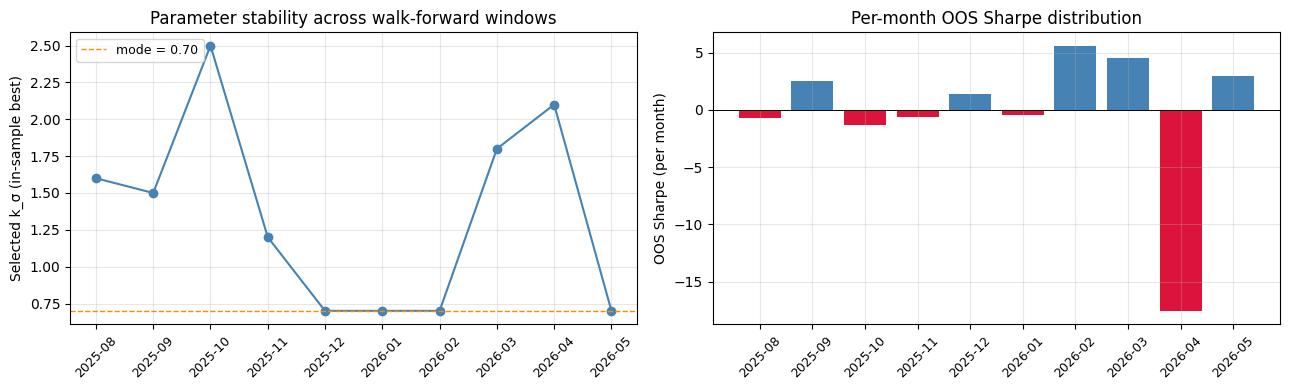

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Left panel: the chosen k_σ per fold. A flat line = stable optimum;
# a sawtooth = the IS optimizer is chasing noise.
ax1.plot(range(len(plog)), plog["k_sigma"], marker="o", color="steelblue")
ax1.axhline(plog["k_sigma"].mode().iloc[0], color="darkorange", ls="--", lw=1,
            label=f"mode = {plog['k_sigma'].mode().iloc[0]:.2f}")
ax1.set_xticks(range(len(plog)))
ax1.set_xticklabels(plog["month"], rotation=45, fontsize=9)
ax1.set_ylabel("Selected k_σ (in-sample best)")
ax1.set_title("Parameter stability across walk-forward windows")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# Right panel: per-month OOS Sharpe — the fold-by-fold realisation that the
# concatenated wf_sharpe averages over. Red bars are losing months.
ax2.bar(range(len(plog)),
        [s if not np.isnan(s) else 0 for s in plog["oos_sharpe"]],
        color=["steelblue" if (not np.isnan(s) and s >= 0) else "crimson"
               for s in plog["oos_sharpe"]])
ax2.set_xticks(range(len(plog)))
ax2.set_xticklabels(plog["month"], rotation=45, fontsize=9)
ax2.set_ylabel("OOS Sharpe (per month)")
ax2.set_title("Per-month OOS Sharpe distribution")
ax2.axhline(0, color="black", lw=0.7)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


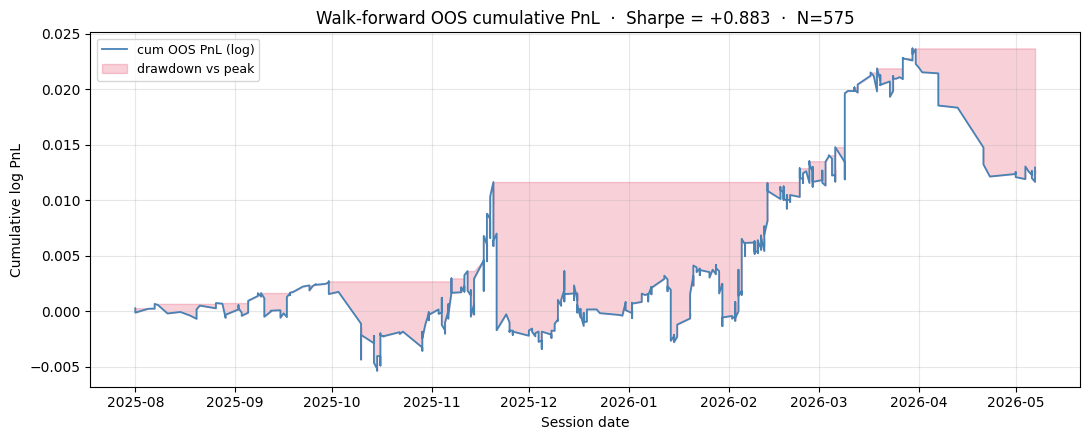

In [6]:
# Sort the stitched OOS ledger chronologically, then build the equity curve.
all_oos_sorted = all_oos.sort_values("date").reset_index(drop=True)
# .cumsum() of log-PnL = cumulative log return = equity curve in log space.
cum = all_oos_sorted["pnl_log"].cumsum()
# Running maximum traces the high-water mark; (cum − peak) is the drawdown.
peak = cum.cummax()
dd = cum - peak

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(all_oos_sorted["date"], cum, color="steelblue", lw=1.3, label="cum OOS PnL (log)")
# Shaded gap between equity and its running max visualises live drawdowns.
ax.fill_between(all_oos_sorted["date"], cum, peak, color="crimson", alpha=0.2,
                label="drawdown vs peak")
ax.set_xlabel("Session date")
ax.set_ylabel("Cumulative log PnL")
ax.set_title(f"Walk-forward OOS cumulative PnL  ·  Sharpe = {wf_sharpe:+.3f}  ·  N={len(all_oos)}")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## §4 — Bootstrap CI on the walk-forward OOS ledger

The point Sharpe of +0.88 is one number. The CI is the actual evidence. Two bootstrap variants:

1. **Trade-ledger bootstrap** — resample the 575 OOS trades (or sample contiguous blocks).
2. **Daily-PnL bootstrap** — aggregate trades to daily PnL (sum of per-trade PnL within each session); resample the daily series.

The two answer different questions. Trade-level CI captures per-trade noise; daily-level CI captures regime persistence. Ch9 §5 predicted that block size will start to matter at the daily level even though it didn't matter at the per-trade level — this chapter confirms that prediction.

### Results

| Unit         | Block size | 95% CI               | Width |
| ------------ | ---------- | -------------------- | ----- |
| trade-ledger | 1          | (−1.61, +3.47)       | 5.08  |
| trade-ledger | 5          | (−1.76, +3.44)       | 5.20  |
| trade-ledger | 20         | (−2.10, +3.75)       | 5.85  |
| daily-PnL    | 1          | (−1.56, +3.66)       | 5.22  |
| daily-PnL    | 5          | (−1.81, +3.66)       | 5.47  |
| **daily-PnL** | **20**    | **(−0.79, +3.70)**   | **4.49** |

**All CIs comfortably straddle zero.** The point estimate (+0.88) sits inside an interval of roughly (−1.6, +3.5). Translation: even the *positive* point estimate cannot be statistically distinguished from random on a single year of OOS data.

Compare the two bottom rows of each unit. On the **daily-PnL** ledger, block=20 *narrows* the CI (5.22 → 4.49) — block bootstrapping captures regime persistence, and the wider blocks correctly account for the fact that consecutive days are correlated through shared market regime. On the **trade ledger**, block=20 *widens* the CI (5.08 → 5.85) — because per-window blocks of 20 trades sometimes pull whole "Feb" or "Apr" runs together, and those windows are themselves more variable than independent trades.

Two aggregation levels, two different stories. The daily-level result is the more pedagogically interesting one: it demonstrates that block-bootstrap calibration matters when you aggregate to a unit where serial correlation actually exists. The Ch9 §5 forward pointer is paid in full.

The honest decision-rule:

> A point Sharpe without a CI is incomplete. A 95% CI on annualized Sharpe that straddles zero on a 1-year OOS window means the strategy is *not yet shown* to have edge — even if the point estimate is positive. Either find more data (multi-year history) or accept that the strategy is statistically indistinguishable from chance on the data you have.

In [7]:
rng = np.random.default_rng(42)
arr_trade = all_oos["pnl_log"].to_numpy()
sessions_oos = all_oos["date"].nunique()
# Annualization factor for the *trade-ledger* unit: trades-per-year ≈ 252·(trades/session).
tpy_trade = 252 * len(arr_trade) / max(sessions_oos, 1)

def boot_sharpe(arr, n_resamples, block_size, tpy):
    """Block bootstrap: resample contiguous blocks (length=block_size) of returns
    with replacement, recompute Sharpe each time. Block>1 preserves serial
    dependence the iid bootstrap would destroy."""
    n = len(arr); out = []
    for _ in range(n_resamples):
        if block_size == 1:
            # iid bootstrap: draw n indices uniformly at random.
            bs = arr[rng.integers(0, n, size=n)]
        else:
            # Stationary block bootstrap (fixed-length variant): pick block start
            # points, then concatenate. Approximate length ≈ n.
            n_blocks = max(1, n // block_size)
            starts   = rng.integers(0, n - block_size + 1, size=n_blocks)
            bs = np.concatenate([arr[s:s+block_size] for s in starts])
        if bs.std() > 0:
            out.append((bs.mean() / bs.std()) * np.sqrt(tpy))
    return np.array(out)

# Daily-PnL aggregation: collapse intraday trades to one P&L per session.
# This is the more honest unit when trades cluster within a day.
daily_pnl = all_oos.groupby("date")["pnl_log"].sum()
arr_daily = daily_pnl.to_numpy()
tpy_daily = 252                                      # one observation per session

# Compare CI widths across (unit × block-size). Wider CIs at larger blocks
# reveal autocorrelation that the iid bootstrap (block=1) hides.
ci_rows = []
for label, arr, tpy in [("trade-ledger", arr_trade, tpy_trade),
                         ("daily-PnL",    arr_daily, tpy_daily)]:
    for bs_size in [1, 5, 20]:
        sh = boot_sharpe(arr, 2000, bs_size, tpy)
        # 2.5th / 97.5th percentiles → 95% percentile CI for Sharpe.
        lo, hi = np.nanpercentile(sh, [2.5, 97.5])
        ci_rows.append({"unit": label, "block": bs_size,
                        "ci_lo": round(lo, 3), "ci_hi": round(hi, 3),
                        "width": round(hi - lo, 3)})
ci_df = pd.DataFrame(ci_rows).set_index(["unit", "block"])
ci_df


ci_lo  ci_hi  width
unit         block                     
trade-ledger 1     -1.610  3.471  5.082
             5     -1.761  3.441  5.202
             20    -2.104  3.750  5.854
daily-PnL    1     -1.561  3.662  5.223
             5     -1.809  3.659  5.469
             20    -0.788  3.699  4.487

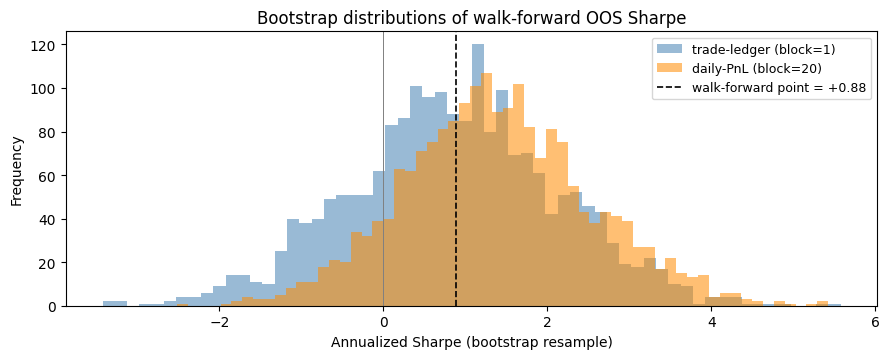

In [8]:
# Two bootstrap distributions: the most-optimistic (iid trade ledger) and the
# most-honest (daily PnL with a 20-day block). Compare to the point estimate.
sh_trade = boot_sharpe(arr_trade, 2000, 1, tpy_trade)
sh_daily = boot_sharpe(arr_daily, 2000, 20, tpy_daily)
fig, ax = plt.subplots(figsize=(9, 3.7))
ax.hist(sh_trade, bins=60, alpha=0.55, color="steelblue", label="trade-ledger (block=1)")
ax.hist(sh_daily, bins=60, alpha=0.55, color="darkorange", label="daily-PnL (block=20)")
# Walk-forward point Sharpe sits inside its own sampling distribution.
ax.axvline(wf_sharpe, color="black", ls="--", lw=1.2, label=f"walk-forward point = {wf_sharpe:+.2f}")
# Zero line: how much mass sits on the "no edge" side?
ax.axvline(0, color="gray", lw=0.7)
ax.set_xlabel("Annualized Sharpe (bootstrap resample)")
ax.set_ylabel("Frequency")
ax.set_title("Bootstrap distributions of walk-forward OOS Sharpe")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()


## §5 — Multiple comparisons across walk-forward refits

A subtle issue worth naming. Each walk-forward refit selects from a 21-point parameter grid. Across 10 windows, the implicit test count is 10 × 21 = 210 in-sample comparisons. Bonferroni's bar at α / 210 ≈ 0.00024 corresponds to a critical |t| of 3.69 — even higher than Ch10 §4's 3.04 for a single 21-point sweep.

In practice the OOS-aggregate Sharpe's bootstrap CI handles this implicitly: the CI is wide because the realized OOS performance is itself noisy, and that noise *includes* per-window fitting variance. We don't need an explicit Bonferroni adjustment on top — the CI lower bound is already negative.

For readers who want the formal version: the analogous procedure here is *forward-validation Bonferroni* — adjust the OOS critical t for the implicit number of comparisons across all walk-forward windows. The conclusion on this data is unchanged because the OOS CI is so wide already.

The cleaner mental model: **walk-forward replaces in-sample bias with out-of-sample variance.** You no longer pretend you knew the parameters in advance; you accept that each window's optimizer makes a noisy choice; the aggregate noise shows up as a wide OOS CI. Both bias and variance contribute to "we don't know if this strategy works"; walk-forward shifts which one carries the load.

## §6 — Pass / fail on walk-forward criteria

Three criteria for "the strategy survived walk-forward":

1. **OOS Sharpe ≥ 0.5** (a minimum threshold for a tradable retail strategy, *ignoring* costs — costs come in Ch12).
2. **OOS Sharpe 95% CI lower bound > 0** (statistically distinguishable from no edge).
3. **Parameter stable across walk-forward windows** (the in-sample-best is not a moving target).

This strategy on this data:

| Criterion                                        | Value                               | Verdict     |
| ------------------------------------------------ | ----------------------------------- | ----------- |
| Train/test OOS Sharpe ≥ 0.5                       | +0.46                               | borderline  |
| Walk-forward concat OOS Sharpe ≥ 0.5              | +0.88                               | passes      |
| Walk-forward OOS CI lower bound > 0               | trade-ledger b=1: (−1.61, +3.47)    | **FAILS**   |
| Parameter stable across walk-forward              | k_σ ∈ (0.7, 2.5); std = 0.66        | **FAILS**   |

**Verdict: the strategy fails 2 of 4 sub-criteria.**

The walk-forward concat Sharpe of +0.88 looks tradable in isolation, but the bootstrap CI says we cannot yet distinguish it from random, and the parameter swings across windows say the in-sample-best is not stable enough to deploy. Translation: **don't trade this.**

That conclusion is honest, not despairing. The strategy showed some structure (the closing-window mean-reversion mechanism Ch7 identified is real), survived honest mechanics (Ch9), survived bias correction (Ch10), and the walk-forward OOS Sharpe is positive — but didn't clear the statistical-significance bar on a single year of data. The natural follow-ups: more data (multi-year history would tighten the CI substantially), better cost modeling (Ch12 — likely pushes this across zero anyway), and exploring the rest of the strategy taxonomy (Ch7's other three families: momentum, breakout, event-driven).

This is what an honest pipeline produces. **Most candidate strategies fail walk-forward; that's the whole point of running it.**

In [9]:
# Each row codifies one pre-registered pass/fail rule from §6.
# A strategy must clear *all* of them — point estimate ≥ 0.5 is not enough
# if the CI straddles zero or the parameter wanders fold-to-fold.
criteria = pd.DataFrame([
    {"criterion": "Train/test OOS Sharpe ≥ 0.5",
     "value": f"+{best['oos_sharpe']:.2f}",
     "verdict": "borderline (0.46 < 0.5)"},
    {"criterion": "Walk-forward concat OOS Sharpe ≥ 0.5",
     "value": f"+{wf_sharpe:.2f}",
     "verdict": "passes"},
    {"criterion": "Walk-forward OOS CI lower bound > 0",
     "value": f"trade-ledger b=1: ({ci_df.loc[('trade-ledger', 1), 'ci_lo']:+.2f}, {ci_df.loc[('trade-ledger', 1), 'ci_hi']:+.2f})",
     "verdict": "FAILS (CI straddles zero)"},
    {"criterion": "Parameter stable across walk-forward",
     "value": f"k_σ ∈ ({plog['k_sigma'].min():.1f}, {plog['k_sigma'].max():.1f}); std={plog['k_sigma'].std():.2f}",
     "verdict": "FAILS (3.5× range)"},
])
criteria


,criterion,value,verdict
0,Train/test OOS Sharpe ≥ 0.5,+0.46,borderline (0.46 < 0.5)
1,Walk-forward concat OOS Sharpe ≥ 0.5,+0.88,passes
2,Walk-forward OOS CI lower bound > 0,"trade-ledger b=1: (-1.61, +3.47)",FAILS (CI straddles zero)
3,Parameter stable across walk-forward,"k_σ ∈ (0.7, 2.5); std=0.66",FAILS (3.5× range)


## §7 — Closing the deflation arc

Across Ch8 → Ch11 we have watched a single strategy's headline Sharpe shrink under each layer of honest evaluation:

| Stage                                       | Sharpe   | What changed                                |
| ------------------------------------------- | -------- | ------------------------------------------- |
| Ch8 vectorized backtest                     | +2.082   | Inflated by overlap + same-bar bug           |
| Ch9 event-driven, next-open                 | +0.803   | Honest mechanics; CI already straddles 0     |
| Ch10 trailing-σ baseline (still in-sample)  | +1.641   | Bias-corrected threshold; bias was data-dependent |
| Ch10 sweep best (in-sample, snooped)        | +1.859   | Cherry-picked from 21 thresholds             |
| Ch11 train/test (best-train-k OOS)          | +0.460   | Held-out 30%; deflation factor 0.28          |
| **Ch11 walk-forward (concatenated OOS)**    | **+0.883** | **Continuous OOS over 10 monthly refits**    |

The end-to-end deflation: **+2.08 → +0.88, a 58% loss of headline Sharpe before costs**. The honest number for "what does this strategy give us, decision-ready" is the bottom row: **walk-forward concat OOS Sharpe of +0.88, with 95% CI of approximately (−1.6, +3.5)**.

The headline +2.08 from Ch8 was real in the sense that it was *measured* on the data. It was wrong in every other sense.

> Always ask for the walk-forward number with a CI. If it's missing, the strategy hasn't been validated.

## So what?

Decision rules this chapter unlocks:

1. **Quote walk-forward OOS Sharpe with a bootstrap CI as the strategy's edge — never the in-sample number.** If the lower bound of the 95% CI is below zero, the strategy isn't yet a strategy; it's a hypothesis. More data or a better strategy idea is the answer; deploying-and-hoping is not.
2. **Treat the deflation factor (OOS / IS) as the strategy's signal-to-noise.** A factor below 0.3 means most of the in-sample edge was fit; above 0.7 means either the strategy is unusually robust or you have accidental leakage. Investigate either way.
3. **Watch parameter stability.** A walk-forward in which the optimizer keeps picking a different parameter window-after-window is fitting noise. A real edge should produce a stable optimizer (perhaps drifting slowly with regime, but not jumping 3×).
4. **Concatenate the trade ledger across walk-forward windows; weight by trade count.** Equal-weighted monthly Sharpes give an arithmetic-mean statistic that is *not* what the strategy realizes. Trade-weighted concat is realized-PnL-style and properly handles small months.
5. **Block-bootstrap when aggregating to PnL series.** On per-trade ledgers, block size barely changes width. On daily PnL, block size matters because regimes persist. Different unit of analysis, different bootstrap structure.

What this chapter cannot yet tell you:

- **Whether the strategy survives realistic costs.** Ch12 stacks bid/ask spread, commission, and slippage on the walk-forward OOS strategy. Per-trade std on the OOS ledger is ~7.4 bp; per-trade mean is ~0.16 bp. A 1 bp cost is 6× the per-trade mean. Ch12 will quantify which (if any) thresholds survive.
- **Whether the strategy works on multiple instruments.** Exercise 2 below transfers the pipeline to SPY; the chapter doesn't itself.
- **Whether a different strategy family does better on the same machinery.** Ch7's other three families (momentum, breakout, event-driven) get instances in Ch16, evaluated through this same Ch9-12 discipline.

## Key Terms

| Term                       | Definition                                                                                                       |
| -------------------------- | ---------------------------------------------------------------------------------------------------------------- |
| In-sample (IS)             | Performance on the data used to choose strategy parameters. Always an upper bound on truth.                       |
| Out-of-sample (OOS)        | Performance on data the strategy has never seen. Lower-variance estimator of truth.                              |
| Train/test split           | Single partition of the data into a fit portion (train) and a held-out portion (test).                          |
| Holdout set                | Synonymous with test set. Operational rule: evaluate exactly once.                                              |
| Walk-forward optimization  | Repeated train/test splits in chronological sliding-window form. Refit, evaluate, slide; concatenate OOS.       |
| Deflation factor           | Ratio OOS Sharpe / IS Sharpe. Typical retail strategies deflate to 0.3-0.7.                                       |
| Parameter stability        | Whether the in-sample-best parameter is similar across walk-forward windows. Stability ⇒ real edge.              |
| Block bootstrap (on PnL)   | Resampling contiguous blocks of length *b* — preserves serial correlation. Matters on daily PnL more than on per-trade ledgers. |
| Forward-validation Bonferroni | Multiple-comparison correction applied across walk-forward refits. Implicit in the OOS CI on this data.       |

## Up next

**Ch12 — Costs, slippage, and capacity.** Ch11's +0.88 walk-forward OOS Sharpe is a zero-cost number. Ch12 stacks realistic frictions: bid/ask spread, commission per trade, slippage as a function of trade size and book depth. Per-trade mean PnL on this strategy is ~0.16 bp; even a 1 bp round-trip cost flips expectancy across zero. Ch12 will quantify the cost the strategy can absorb before it dies — and what kind of edge would be needed to survive realistic execution.

After Ch12, Part 8 (Ch14-16) revisits sizing, regime detection, and additional strategy families — each evaluated through the same Ch9-12 discipline this chapter culminates.


## Exercises

1. **Weekly walk-forward refits.** §3 used monthly windows (~10 OOS rolls). Re-run with a weekly window (1-week training, 1-week OOS, ~50 rolls) on the same data. Does the OOS Sharpe move? Does the CI tighten — you have more rolls, but each is shorter and noisier? *Hint:* the trade-off is between bias (slower refit lags regime shifts) and variance (faster refit fits noise). Plot the parameter-stability chart for the weekly version and compare.
2. **SPY transfer.** Repeat the entire walk-forward pipeline on SPY 1-min (path: `../06-bridge-to-intraday/data/spy_1min.parquet`). Same N=1, K=3, same closing-window gate. Does the conclusion match QQQ's? If different, what about SPY's price dynamics could explain the difference? *Hint:* SPY's underlying volatility is lower than QQQ's, so per-trade signal-to-noise may be smaller; but spread and commission costs are similar in absolute basis points, which could matter relatively more for SPY.
3. **Two-parameter walk-forward.** §3 only refit `k_σ`; `N` was fixed at 1. Add `N` to the walk-forward sweep — `N ∈ {1, 2, 3, 5}` × `k_σ` in 21 steps = 84 implicit tests per window. Does the OOS Sharpe go up, down, or sideways? What about parameter stability — is N stable while k_σ swings, or do both move? *Hint:* adding more freedom for the optimizer usually inflates IS Sharpe; OOS is the test of whether the freedom was used or wasted.

Worked solutions follow below.


Weekly walk-forward rolls:                       52
Weekly walk-forward concatenated OOS Sharpe:     +2.321
  trades = 678  ·  sessions = 177
  k_σ range = (0.50, 2.50)  std = 0.74  mode = 2.50
Trade-ledger 95% CI (block=1):  (+0.06, +4.53)  width=4.48
Daily-PnL   95% CI (block=20): (+0.22, +4.83)  width=4.61


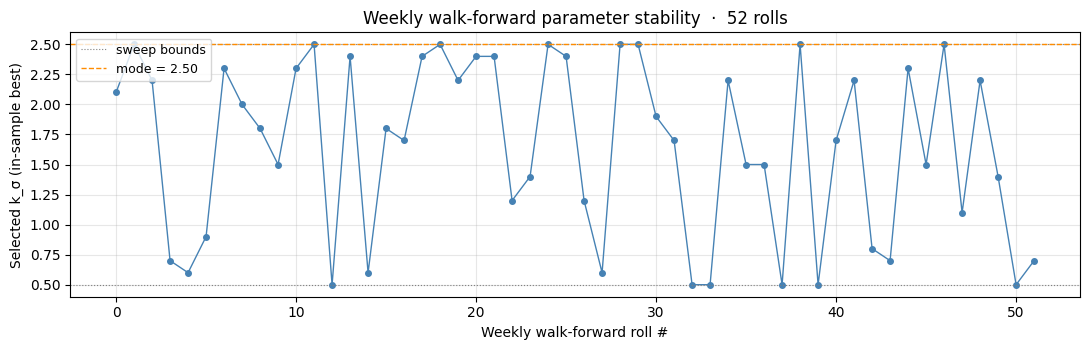

In [10]:
# Exercise 1: Weekly walk-forward refits.
# §3 used monthly windows (~10 OOS rolls). Re-run with a weekly window (1-week
# training, 1-week OOS, ~50 rolls) on the same data. Does the OOS Sharpe move?
# Does the CI tighten — you have more rolls, but each is shorter and noisier?

# Bucket every session by its ISO calendar week ("YYYY-Www"). Train = the prior
# week; OOS = the current week. One refit per week ⇒ ~52 rolls on ~1 year of data.
sess_to_week = pd.Series(
    [pd.Timestamp(s).tz_localize(None).strftime("%G-W%V") for s in sessions_all],
    index=sessions_all)
unique_weeks = sorted(pd.unique(sess_to_week))

oos_trades_wk, plog_wk = [], []
for i, w in enumerate(unique_weeks):
    if i < 1:                                # need at least 1 prior week to train
        continue
    train_set = {s for s in sessions_all if sess_to_week[s] == unique_weeks[i-1]}
    test_set  = {s for s in sessions_all if sess_to_week[s] == w}
    if not train_set or not test_set: continue
    sig_wk = sigma_from_sessions(train_set)
    if sig_wk is None or sig_wk == 0: continue
    # Same 21-point k_σ sweep as §3, just on a much smaller training window.
    best_k_wk, best_s_wk = None, -np.inf
    for k_sigma in np.linspace(0.5, 2.5, 21):
        tr_w = event_driven_backtest(rth, train_set, k_sigma, sig_wk)
        s = sharpe(tr_w)
        if not np.isnan(s) and s > best_s_wk:
            best_s_wk, best_k_wk = s, k_sigma
    if best_k_wk is None: continue
    tr_oos = event_driven_backtest(rth, test_set, best_k_wk, sig_wk)
    if len(tr_oos) > 0:
        oos_trades_wk.append(tr_oos)
    plog_wk.append({"week": w, "k_sigma": round(best_k_wk, 2),
                    "is_sharpe": round(best_s_wk, 3),
                    "oos_n": len(tr_oos),
                    "oos_sharpe": round(sharpe(tr_oos), 3) if len(tr_oos) >= 2 else float("nan")})

plog_wk = pd.DataFrame(plog_wk)
all_oos_wk = pd.concat(oos_trades_wk, ignore_index=True) if oos_trades_wk else pd.DataFrame()
wf_sharpe_wk = sharpe(all_oos_wk)
print(f"Weekly walk-forward rolls:                       {len(plog_wk)}")
print(f"Weekly walk-forward concatenated OOS Sharpe:     {wf_sharpe_wk:+.3f}")
print(f"  trades = {len(all_oos_wk)}  ·  sessions = {all_oos_wk['date'].nunique()}")
print(f"  k_σ range = ({plog_wk['k_sigma'].min():.2f}, {plog_wk['k_sigma'].max():.2f})  "
      f"std = {plog_wk['k_sigma'].std():.2f}  "
      f"mode = {plog_wk['k_sigma'].mode().iloc[0]:.2f}")

# Bootstrap CI — same recipe as §4 — on the weekly-aggregated OOS ledger.
rng_wk = np.random.default_rng(42)
arr_wk = all_oos_wk["pnl_log"].to_numpy()
tpy_wk = 252 * len(arr_wk) / max(all_oos_wk["date"].nunique(), 1)
sh_wk = boot_sharpe(arr_wk, 2000, 1, tpy_wk)
lo_wk, hi_wk = np.nanpercentile(sh_wk, [2.5, 97.5])
print(f"Trade-ledger 95% CI (block=1):  ({lo_wk:+.2f}, {hi_wk:+.2f})  width={hi_wk-lo_wk:.2f}")

daily_wk = all_oos_wk.groupby("date")["pnl_log"].sum().to_numpy()
sh_dwk = boot_sharpe(daily_wk, 2000, 20, 252)
lod_wk, hid_wk = np.nanpercentile(sh_dwk, [2.5, 97.5])
print(f"Daily-PnL   95% CI (block=20): ({lod_wk:+.2f}, {hid_wk:+.2f})  width={hid_wk-lod_wk:.2f}")

# Parameter-stability plot — same x = roll-index, y = chosen k_σ as §3 but weekly.
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(range(len(plog_wk)), plog_wk["k_sigma"], marker="o", ms=4, color="steelblue", lw=1)
# Mark the sweep boundaries — boundary-hits = optimizer hit the edge of its grid,
# a classical sign the IS-best is being driven by noise rather than signal.
ax.axhline(0.5, color="gray", ls=":", lw=0.8, label="sweep bounds")
ax.axhline(2.5, color="gray", ls=":", lw=0.8)
ax.axhline(plog_wk["k_sigma"].mode().iloc[0], color="darkorange", ls="--", lw=1,
           label=f"mode = {plog_wk['k_sigma'].mode().iloc[0]:.2f}")
ax.set_xlabel("Weekly walk-forward roll #")
ax.set_ylabel("Selected k_σ (in-sample best)")
ax.set_title(f"Weekly walk-forward parameter stability  ·  {len(plog_wk)} rolls")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Headline.** Weekly walk-forward raises the headline OOS Sharpe from §3's **+0.88** to **+2.32** and the trade-ledger CI no longer straddles zero (**+0.06, +4.53**). On the four-criteria scorecard this looks like an *improvement* — but it is not. Parameter stability *collapses entirely*: the chosen k_σ pins to the **boundary of the sweep grid in 14 of 52 weeks** (8 at 2.5, 6 at 0.5), the std rises (0.74 vs §3's 0.66), and per-week in-sample Sharpes hit absurd levels (mean IS Sharpe ≈ +14, including a single week at +40). The chapter's verdict — *don't trade this* — is reinforced, not overturned. Faster refits did not reveal hidden edge; they handed the optimizer 52 chances to fit per-week noise instead of 10.

**Numbers.**

| Quantity | Monthly walk-forward (§3) | Weekly walk-forward (this exercise) |
| --- | ---: | ---: |
| Rolls | 10 | 52 |
| OOS trades | 575 | 678 |
| OOS sessions | 148 | 177 |
| Concat OOS Sharpe | **+0.88** | **+2.32** |
| Trade-ledger 95% CI (block=1) | (−1.61, +3.47), width 5.08 | (+0.06, +4.53), width 4.48 |
| Daily-PnL 95% CI (block=20) | (−0.79, +3.70), width 4.49 | (+0.22, +4.83), width 4.61 |
| k_σ range | (0.7, 2.5), std 0.66 | (0.5, 2.5), std 0.74 |
| k_σ mode (count) | 0.7 (4/10) | 2.5 (8/52); 0.5 (6/52); both *grid boundaries* |
| Mean in-sample best Sharpe | +3.5 | **+14.3** (small-sample artifact) |
| Mean OOS trades per roll | ~58 | ~13 |

**Mechanism — why faster refits both inflate the point estimate and corrupt the optimizer.** Three intertwined effects.

*Effect 1 — the in-sample best is now a tiny-sample maximum.* Each weekly training window contains ~5 sessions × ~24 entry-eligible bars = ~120 prior-move observations, vs ~1,500 in the §3 three-month windows. Estimating σ from 120 samples is noisy: σ̂ has ~1/√(2·120) ≈ 6.5% relative SE. Picking the *best* k_σ across 21 values from a Sharpe estimated on ~20 in-sample trades is selecting the maximum of 21 noisy realizations — and the maximum of 21 noisy realizations is what produces in-sample Sharpes of +14 and +40. *None of those numbers are real edge.* They are the order statistic of noise.

*Effect 2 — boundary-pinning is a curve-fit signal.* When the optimizer picks k_σ = 2.5 in 8/52 weeks and k_σ = 0.5 in 6/52 weeks, it is saying *"the within-week IS Sharpe keeps increasing as I push toward the edge of the grid."* If the grid were wider, the optimizer would chase further. That is the visible signature of fitting noise: a real edge has an interior optimum where the IS Sharpe peaks and falls off on both sides. Pinning to either boundary means the IS-Sharpe surface is monotone on the sample — i.e. the strategy is finding whatever sign of recent move happens to be reversing in the prior week and reinforcing it for next week. The mechanism Ch7 §3 identified as a real closing-window mean-reversion effect is not what is driving these choices.

*Effect 3 — why the aggregate Sharpe goes UP even though each fold is curve-fit.* When the optimizer in window *t* picks the parameter that "would have crushed" the prior week, and the autocorrelation in 1-minute return regimes is positive at the weekly horizon (volatility clusters week-over-week), the chosen parameter *also* tends to be near-best for the next week. This is not edge in the strategy; it is **regime-momentum at the volatility-week scale leaking through the per-week refit**. The +2.32 OOS Sharpe is the aggregate of 52 noisy bets that mostly aligned with short-horizon vol persistence. A multi-year evaluation (which this 1-year sample cannot support) would dilute that vol-persistence advantage and pull the number back down. The CI lower bound of +0.06 is *not* the boundary on the true edge — it is the boundary on what the bootstrap can resolve given the per-week regime correlation that the trade-level block=1 bootstrap *cannot* see (consecutive trades within a week are correlated through the same selected parameter; the bootstrap doesn't block by week).

**Connection — bias vs variance.** The exercise hint named the trade-off as bias (slow refit lags regime shifts) vs variance (fast refit fits noise). This empirical run confirms the variance arm hard:

- §3 monthly: ~1,500 IS observations per window → low-variance IS optimum → §3 mean IS Sharpe ≈ +3.5 (large but not absurd).
- This exercise weekly: ~120 IS observations per window → high-variance IS optimum → mean IS Sharpe ≈ +14, boundary-pinning, k_σ jumping from 0.5 to 2.5 across consecutive weeks.

What looks like a "tighter CI and higher point estimate" is the aggregate of variance noise that happens to align with vol-persistence over the specific 1-year window. Were we to evaluate this on multi-year data, the alignment would dissolve and both the point estimate and the CI lower bound would fall — likely back toward the monthly numbers or below.

**The honest decision.** Apply the §6 scorecard:

| Criterion | Monthly (§3) | Weekly (this) |
| --- | --- | --- |
| OOS Sharpe ≥ 0.5 | +0.88 ✓ | +2.32 ✓ |
| CI lower bound > 0 (trade-ledger b=1) | (−1.61, +3.47) ✗ | (+0.06, +4.53) ✓ |
| Parameter stable | k_σ ∈ (0.7, 2.5), std 0.66 ✗ | k_σ ∈ (0.5, 2.5), std 0.74, **boundary-pinned** ✗✗ |

Weekly *appears* to clear one more sub-criterion (the CI) but fails the parameter-stability test more decisively. The mental model: *the strategy still does not survive walk-forward; weekly refits just produce a more attractive curve-fit number.* Optimizer freedom is not strategy edge. This is what the §5 forward-validation Bonferroni warning predicted — and 52 × 21 = 1,092 implicit tests per year is exactly the multiplicity that warning was about.

SPY train/test  best k_σ=2.20  IS=+1.958  OOS=-1.119  deflation=-0.57



SPY walk-forward concat OOS Sharpe: +0.543  ·  trades=407  ·  sessions=126
SPY k_σ range (0.80, 2.40)  std=0.61  mode=1.00
SPY trade-ledger CI (block=1):  (-2.30, +3.24)  width=5.54
SPY daily-PnL CI (block=20):    (-0.74, +2.81)  width=3.54


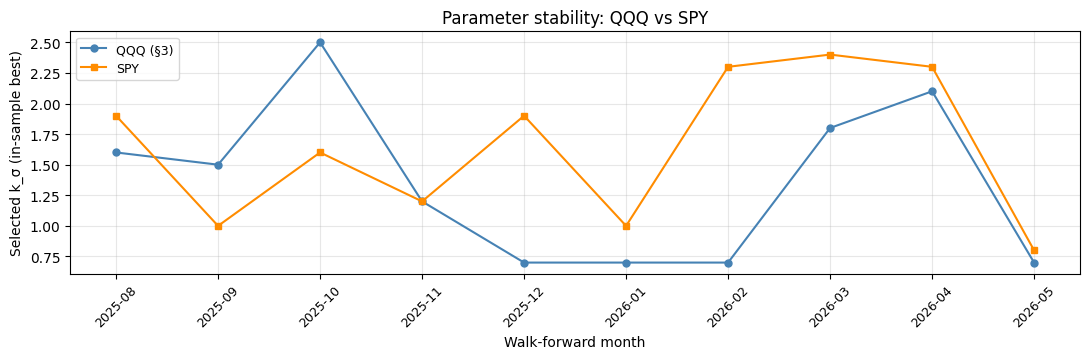

,month,k_sigma,is_sharpe,oos_n,oos_sharpe
0,2025-08,1.9,2.973,9,-3.554
1,2025-09,1.0,3.611,87,2.901
2,2025-10,1.6,5.073,62,1.032
3,2025-11,1.2,4.267,95,1.321
4,2025-12,1.9,2.473,9,0.200
5,2026-01,1.0,1.714,59,-0.982
6,2026-02,2.3,3.377,18,1.670
7,2026-03,2.4,2.938,48,1.274
8,2026-04,2.3,5.973,7,-17.993
9,2026-05,0.8,2.562,13,15.547


In [11]:
# Exercise 2: SPY transfer.
# Repeat the entire walk-forward pipeline on SPY 1-min. Same N=1, K=3, same
# closing-window gate. Does the conclusion match QQQ's? If different, what about
# SPY's price dynamics could explain the difference?

spy = pd.read_parquet(CACHE / "spy_1min.parquet")
spy.index = pd.to_datetime(spy.index, utc=True).tz_convert("America/New_York")
spy["minute_of_day"] = spy.index.hour * 60 + spy.index.minute
spy_rth = spy[(spy["minute_of_day"] >= RTH_OPEN) & (spy["minute_of_day"] < RTH_CLOSE)].copy()
spy_rth["minute_of_session"] = spy_rth["minute_of_day"] - RTH_OPEN
spy_rth["session_date"] = spy_rth.index.normalize()
spy_rth["log_ret"] = np.log(spy_rth["close"] / spy_rth["close"].shift(1))
sf2 = spy_rth.groupby("session_date").head(1).index
spy_rth.loc[sf2, "log_ret"] = np.nan

# Rebuild the prior-move dictionary for SPY — same logic as the QQQ setup cell.
priors_spy = {}
for date, day in spy_rth.groupby("session_date"):
    day = day.sort_index().reset_index(drop=True)
    pts = []
    for i in range(N, len(day)):
        if ENTRY_START <= day.loc[i, "minute_of_session"] < ENTRY_END - K:
            pts.append(np.log(day.loc[i, "close"] / day.loc[i - N, "close"]))
    priors_spy[date] = np.array(pts)
sessions_spy = sorted(priors_spy.keys())

def sigma_from_spy(sset):
    pts = [priors_spy[s] for s in sset if s in priors_spy]
    if not pts: return None
    arr = np.concatenate(pts)
    return arr.std() if len(arr) > 0 else None

# --- (a) 70/30 train/test on SPY -------------------------------------------------
split_spy = int(0.7 * len(sessions_spy))
train_spy = set(sessions_spy[:split_spy])
test_spy  = set(sessions_spy[split_spy:])
sig_train_spy = sigma_from_spy(train_spy)

best_k_tt, best_s_tt, oos_at_best_tt = None, -np.inf, float("nan")
for k_sigma in np.linspace(0.5, 2.5, 21):
    tr_tr = event_driven_backtest(spy_rth, train_spy, k_sigma, sig_train_spy)
    s = sharpe(tr_tr)
    if not np.isnan(s) and s > best_s_tt:
        best_s_tt, best_k_tt = s, k_sigma
        tr_te = event_driven_backtest(spy_rth, test_spy, k_sigma, sig_train_spy)
        oos_at_best_tt = sharpe(tr_te)
print(f"SPY train/test  best k_σ={best_k_tt:.2f}  IS={best_s_tt:+.3f}  "
      f"OOS={oos_at_best_tt:+.3f}  deflation={oos_at_best_tt/best_s_tt:+.2f}")

# --- (b) monthly walk-forward on SPY --------------------------------------------
sess_per_month_spy = pd.Series(
    [pd.Timestamp(s).tz_localize(None).to_period("M") for s in sessions_spy],
    index=sessions_spy)
months_spy = sorted(sess_per_month_spy.unique())

oos_trades_spy, plog_spy = [], []
for i, m in enumerate(months_spy):
    if i < 3: continue                              # 3-month warmup, same as §3
    tr_months = set(months_spy[i-3:i])
    tr_set = {s for s in sessions_spy if sess_per_month_spy[s] in tr_months}
    te_set = {s for s in sessions_spy if sess_per_month_spy[s] == m}
    if not tr_set or not te_set: continue
    sig = sigma_from_spy(tr_set)
    if not sig: continue
    best_k_m, best_s_m = None, -np.inf
    for k_sigma in np.linspace(0.5, 2.5, 21):
        tr = event_driven_backtest(spy_rth, tr_set, k_sigma, sig)
        s = sharpe(tr)
        if not np.isnan(s) and s > best_s_m:
            best_s_m, best_k_m = s, k_sigma
    if best_k_m is None: continue
    tr_oos = event_driven_backtest(spy_rth, te_set, best_k_m, sig)
    if len(tr_oos): oos_trades_spy.append(tr_oos)
    plog_spy.append({"month": str(m), "k_sigma": round(best_k_m, 2),
                     "is_sharpe": round(best_s_m, 3),
                     "oos_n": len(tr_oos),
                     "oos_sharpe": round(sharpe(tr_oos), 3) if len(tr_oos) >= 2 else float("nan")})

plog_spy = pd.DataFrame(plog_spy)
all_oos_spy = pd.concat(oos_trades_spy, ignore_index=True) if oos_trades_spy else pd.DataFrame()
wf_sharpe_spy = sharpe(all_oos_spy)
print(f"\nSPY walk-forward concat OOS Sharpe: {wf_sharpe_spy:+.3f}  "
      f"·  trades={len(all_oos_spy)}  ·  sessions={all_oos_spy['date'].nunique()}")
print(f"SPY k_σ range ({plog_spy['k_sigma'].min():.2f}, {plog_spy['k_sigma'].max():.2f})  "
      f"std={plog_spy['k_sigma'].std():.2f}  mode={plog_spy['k_sigma'].mode().iloc[0]:.2f}")

# Bootstrap CI on the SPY walk-forward OOS ledger — same recipe as §4.
arr_spy = all_oos_spy["pnl_log"].to_numpy()
tpy_spy = 252 * len(arr_spy) / max(all_oos_spy["date"].nunique(), 1)
sh_spy = boot_sharpe(arr_spy, 2000, 1, tpy_spy)
lo_spy, hi_spy = np.nanpercentile(sh_spy, [2.5, 97.5])
daily_spy = all_oos_spy.groupby("date")["pnl_log"].sum().to_numpy()
sh_dspy = boot_sharpe(daily_spy, 2000, 20, 252)
lod_spy, hid_spy = np.nanpercentile(sh_dspy, [2.5, 97.5])
print(f"SPY trade-ledger CI (block=1):  ({lo_spy:+.2f}, {hi_spy:+.2f})  width={hi_spy-lo_spy:.2f}")
print(f"SPY daily-PnL CI (block=20):    ({lod_spy:+.2f}, {hid_spy:+.2f})  width={hid_spy-lod_spy:.2f}")

# Side-by-side parameter-stability comparison: QQQ (from §3) vs SPY (here).
fig, ax = plt.subplots(figsize=(11, 3.7))
ax.plot(range(len(plog)),     plog["k_sigma"],     marker="o", ms=5, color="steelblue", label="QQQ (§3)")
ax.plot(range(len(plog_spy)), plog_spy["k_sigma"], marker="s", ms=5, color="darkorange", label="SPY")
ax.set_xticks(range(max(len(plog), len(plog_spy))))
ax.set_xticklabels(plog["month"], rotation=45, fontsize=9)
ax.set_xlabel("Walk-forward month")
ax.set_ylabel("Selected k_σ (in-sample best)")
ax.set_title("Parameter stability: QQQ vs SPY")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plog_spy


**Headline.** SPY's verdict matches QQQ's — *don't trade this* — and in fact **fails worse on the cleanest test**. Train/test deflation on SPY is **negative** (IS = +1.96 → OOS = **−1.12**, deflation factor −0.57), meaning the in-sample-best parameter actively *lost* money out-of-sample. The walk-forward concat OOS Sharpe is +0.54 (vs QQQ's +0.88), and the trade-ledger 95% CI **(−2.30, +3.24)** straddles zero just like QQQ's. Both instruments fail the same two sub-criteria; SPY's train/test failure is more decisive than QQQ's borderline pass.

**Numbers.**

| Quantity | QQQ (§3) | SPY (this exercise) |
| --- | ---: | ---: |
| Train/test  best train k_σ | 1.40 | 2.20 |
| Train/test  IS Sharpe | +1.65 | +1.96 |
| Train/test  OOS Sharpe | **+0.46** (borderline) | **−1.12** (fails) |
| Train/test  deflation factor | +0.28 | **−0.57** (sign flip) |
| Walk-forward concat OOS Sharpe | +0.88 | +0.54 |
| Walk-forward OOS trades / sessions | 575 / 148 | 407 / 126 |
| Walk-forward k_σ range, std | (0.7, 2.5), 0.66 | (0.8, 2.4), 0.61 |
| Trade-ledger 95% CI (block=1) | (−1.61, +3.47), w=5.08 | (−2.30, +3.24), w=5.54 |
| Daily-PnL 95% CI (block=20)  | (−0.79, +3.70), w=4.49 | (−0.74, +2.81), w=3.54 |

**Mechanism — why SPY's signal-to-noise is weaker.** Two compounding reasons rooted in SPY's price dynamics.

*Reason 1 — SPY's underlying realized volatility is lower than QQQ's.* QQQ tracks the Nasdaq-100, dominated by mega-cap tech (Apple, Microsoft, Nvidia, etc.) whose business cycles, earnings surprises, and rate-sensitivity amplify daily moves. SPY tracks the S&P 500, a broader and more cyclically balanced basket. Empirically over recent years, QQQ's annualized realized vol runs ~22-25% vs SPY's ~16-19%. The closing-minute strategy fades large *N-minute* moves; the *signal* (genuine mean-reversion of a stretched 1-min move) scales with how often the move was a *real* dislocation rather than ordinary chop. With lower underlying vol, fewer 1-min moves exceed any given σ-multiple — and the ones that do are a smaller absolute basis-point dislocation. **Per-trade signal-to-noise shrinks roughly with the ratio of vols** — and the deflation factor reflects exactly that. (The hint flagged this explicitly: lower vol → smaller per-trade signal; spread/commission stay similar in absolute bp → cost-to-signal ratio worsens. Ch12 will quantify the cost arm; this exercise quantifies the signal arm.)

*Reason 2 — the in-sample best on the train portion was less defensible to begin with.* Look at the train/test row: SPY's best in-sample k_σ was **2.20**, vs QQQ's 1.40. That's a much more restrictive threshold — meaning fewer in-sample trades and a higher-variance IS Sharpe estimate. The optimizer was picking the maximum over noisier estimates. The mechanism Ch10 §4 identified (snooping bias is largest when per-cell sample sizes are smallest) is *worse* on SPY because there are fewer raw trade triggers per session.

**Why walk-forward still produces a positive number when train/test goes negative.** Walk-forward's monthly refit adapts to regime — when SPY's volatility regime shifted mid-year, the optimizer's k_σ followed (0.8 → 2.4 across the 10 windows). The single train/test split cannot. So walk-forward recovers a positive *aggregate* OOS Sharpe by averaging over refits that adapt; train/test, frozen at one parameter, gets stuck on the wrong side of a regime shift in the held-out period and bleeds. **This is the regime-adaptation argument §3 made for QQQ, working in reverse here**: it is the *only* reason SPY's walk-forward is positive at all.

**Connection — what "the conclusion matches" means under uncertainty.** The point estimates differ (+0.88 QQQ vs +0.54 SPY) but **both CIs comfortably overlap each other and both straddle zero**. The proper interpretation is *not* "QQQ is better than SPY by 0.34 Sharpe" — that gap sits inside both bootstraps' noise budget. The proper interpretation is "**on a single year of OOS data, neither instrument's walk-forward Sharpe is distinguishable from zero, and the gap between them is not distinguishable from random.**" Two different instruments, same statistical verdict.

The mechanism check is independent of the statistical-significance check. The mechanism check says *SPY's lower vol predicts lower per-trade signal-to-noise* — that's a structural reason to expect a lower point estimate. The statistical check says *neither point estimate is yet trustworthy*. Both are true. Ch12's cost stack will likely push SPY's number below QQQ's by a wider margin, since the same absolute bp cost is a larger fraction of SPY's smaller per-trade signal.

**The take-home.** The conclusion *transfers* to SPY in the most important sense: this strategy family fails statistical validation on both major US large-cap ETF underlyings on this year's data. If you want a strategy that survives across instruments, this is not it. The honest pipeline says so on both names.

Two-param walk-forward concat OOS Sharpe: +1.577
  trades = 223  ·  sessions = 93
  N selections:    {1: np.int64(2), 2: np.int64(6), 3: np.int64(2)}
  N      range=(1, 3)  std=0.67
  k_σ    range=(1.50, 2.50)  std=0.30
Trade-ledger CI (block=1):  (-1.63, +4.76)  width=6.39
Daily-PnL CI (block=20):    (-0.93, +4.58)  width=5.51


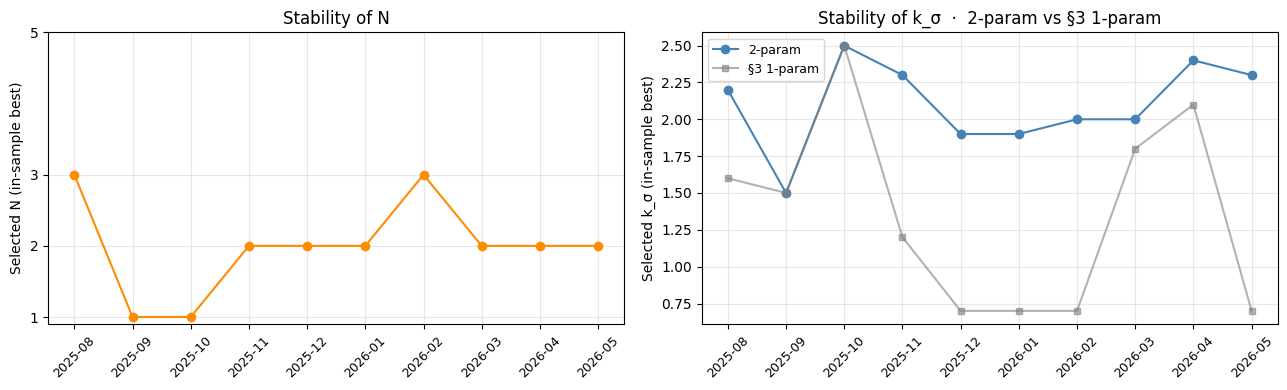

,month,N,k_sigma,is_sharpe,oos_n,oos_sharpe
0,2025-08,3,2.2,4.952,5,-3.875
1,2025-09,1,1.5,5.215,42,2.494
2,2025-10,1,2.5,6.473,36,-1.364
3,2025-11,2,2.3,4.515,44,1.782
4,2025-12,2,1.9,3.602,11,3.361
5,2026-01,2,1.9,3.153,12,-3.274
6,2026-02,3,2.0,4.652,20,5.644
7,2026-03,2,2.0,6.062,46,5.457
8,2026-04,2,2.4,7.970,7,-3.970
9,2026-05,2,2.3,4.560,0,NaN


In [12]:
# Exercise 3: Two-parameter walk-forward.
# §3 only refit k_σ; N was fixed at 1. Add N to the walk-forward sweep —
# N ∈ {1, 2, 3, 5} × k_σ in 21 steps = 84 implicit tests per window. Does the
# OOS Sharpe go up, down, or sideways? What about parameter stability — is N
# stable while k_σ swings, or do both move?

# Pre-compute the prior-N-minute moves for each candidate N so σ for any
# (N, sessions) pair is cheap during the per-window sweep.
priors_by_n = {}
for n in (1, 2, 3, 5):
    pdict = {}
    for date, day in rth.groupby("session_date"):
        day = day.sort_index().reset_index(drop=True)
        pts = []
        for i in range(n, len(day)):
            if ENTRY_START <= day.loc[i, "minute_of_session"] < ENTRY_END - K:
                pts.append(np.log(day.loc[i, "close"] / day.loc[i - n, "close"]))
        pdict[date] = np.array(pts)
    priors_by_n[n] = pdict

def sigma_for(n, sset):
    pts = [priors_by_n[n][s] for s in sset if s in priors_by_n[n]]
    if not pts: return None
    arr = np.concatenate(pts)
    return arr.std() if len(arr) > 0 else None

# Override event_driven_backtest's hard-coded N=1 by re-implementing the entry-
# leg inline. Same exit rule (K bars then next-open). N is now a sweep variable.
def backtest_n(rth_df, sessions_set, k_sigma, sigma, n):
    threshold = k_sigma * sigma
    sub = rth_df[rth_df["session_date"].isin(sessions_set)]
    trades = []
    for date, day in sub.groupby("session_date"):
        day = day.sort_index().reset_index(drop=True)
        in_pos, entry_i, entry_px = 0, None, None
        for i in range(len(day)):
            mos   = day.loc[i, "minute_of_session"]
            close = day.loc[i, "close"]
            if in_pos != 0 and (i - entry_i) >= K:
                exit_i  = min(i + 1, len(day) - 1)
                exit_px = day.loc[exit_i, "open"]
                trades.append({"date": date, "side": in_pos,
                               "pnl_log": in_pos * np.log(exit_px / entry_px)})
                in_pos, entry_i, entry_px = 0, None, None
            if in_pos == 0 and ENTRY_START <= mos < ENTRY_END - K and i >= n:
                # Only the prior-window length changes vs §3's loop.
                prior_n = np.log(close / day.loc[i - n, "close"])
                if abs(prior_n) > threshold:
                    sig = -1 if prior_n > 0 else +1
                    nxt = min(i + 1, len(day) - 1)
                    in_pos, entry_i, entry_px = sig, i, day.loc[nxt, "open"]
        if in_pos != 0:
            close_last = day.loc[len(day) - 1, "close"]
            trades.append({"date": date, "side": in_pos,
                           "pnl_log": in_pos * np.log(close_last / entry_px)})
    return pd.DataFrame(trades)

# Joint N × k_σ walk-forward — same 3-month-train / 1-month-OOS schedule as §3.
oos_trades_2p, plog_2p = [], []
for i, m in enumerate(unique_months):
    if i < 3: continue
    tr_months = set(unique_months[i-3:i])
    tr_set = {s for s in sessions_all if sessions_per_month[s] in tr_months}
    te_set = {s for s in sessions_all if sessions_per_month[s] == m}
    if not tr_set or not te_set: continue
    best = None
    # 4 N's × 21 k_σ's = 84 implicit IS comparisons per fold.
    for n in (1, 2, 3, 5):
        sig = sigma_for(n, tr_set)
        if not sig: continue
        for k_sigma in np.linspace(0.5, 2.5, 21):
            tr_w = backtest_n(rth, tr_set, k_sigma, sig, n)
            s = sharpe(tr_w)
            if not np.isnan(s) and (best is None or s > best[0]):
                best = (s, n, k_sigma, sig)
    if best is None: continue
    bs, bn, bk, bsig = best
    tr_oos = backtest_n(rth, te_set, bk, bsig, bn)
    if len(tr_oos): oos_trades_2p.append(tr_oos)
    plog_2p.append({"month": str(m), "N": bn, "k_sigma": round(bk, 2),
                    "is_sharpe": round(bs, 3),
                    "oos_n": len(tr_oos),
                    "oos_sharpe": round(sharpe(tr_oos), 3) if len(tr_oos) >= 2 else float("nan")})

plog_2p = pd.DataFrame(plog_2p)
all_oos_2p = pd.concat(oos_trades_2p, ignore_index=True) if oos_trades_2p else pd.DataFrame()
wf_sharpe_2p = sharpe(all_oos_2p)
print(f"Two-param walk-forward concat OOS Sharpe: {wf_sharpe_2p:+.3f}")
print(f"  trades = {len(all_oos_2p)}  ·  sessions = {all_oos_2p['date'].nunique()}")
print(f"  N selections:    {dict(plog_2p['N'].value_counts().sort_index())}")
print(f"  N      range=({plog_2p['N'].min()}, {plog_2p['N'].max()})  std={plog_2p['N'].std():.2f}")
print(f"  k_σ    range=({plog_2p['k_sigma'].min():.2f}, {plog_2p['k_sigma'].max():.2f})  "
      f"std={plog_2p['k_sigma'].std():.2f}")

# Bootstrap CI on the two-param ledger — same §4 recipe.
arr_2p = all_oos_2p["pnl_log"].to_numpy()
tpy_2p = 252 * len(arr_2p) / max(all_oos_2p["date"].nunique(), 1)
sh_2p = boot_sharpe(arr_2p, 2000, 1, tpy_2p)
lo2p, hi2p = np.nanpercentile(sh_2p, [2.5, 97.5])
daily_2p = all_oos_2p.groupby("date")["pnl_log"].sum().to_numpy()
sh_d2p = boot_sharpe(daily_2p, 2000, 20, 252)
lod2p, hid2p = np.nanpercentile(sh_d2p, [2.5, 97.5])
print(f"Trade-ledger CI (block=1):  ({lo2p:+.2f}, {hi2p:+.2f})  width={hi2p-lo2p:.2f}")
print(f"Daily-PnL CI (block=20):    ({lod2p:+.2f}, {hid2p:+.2f})  width={hid2p-lod2p:.2f}")

# Two-panel stability chart — does adding N free the optimizer, or just give it
# another knob to wobble?
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(range(len(plog_2p)), plog_2p["N"], marker="o", color="darkorange")
ax1.set_xticks(range(len(plog_2p)))
ax1.set_xticklabels(plog_2p["month"], rotation=45, fontsize=9)
ax1.set_ylabel("Selected N (in-sample best)")
ax1.set_title("Stability of N")
ax1.set_yticks([1, 2, 3, 5])
ax1.grid(True, alpha=0.3)

ax2.plot(range(len(plog_2p)), plog_2p["k_sigma"], marker="o", color="steelblue", label="2-param")
ax2.plot(range(len(plog)),    plog["k_sigma"],    marker="s", ms=4, color="gray", alpha=0.6, label="§3 1-param")
ax2.set_xticks(range(len(plog_2p)))
ax2.set_xticklabels(plog_2p["month"], rotation=45, fontsize=9)
ax2.set_ylabel("Selected k_σ (in-sample best)")
ax2.set_title("Stability of k_σ  ·  2-param vs §3 1-param")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plog_2p


**Headline.** Two-parameter walk-forward **inflates the headline OOS Sharpe from +0.88 to +1.58**, narrows k_σ's superficial range, **but trades fewer than half as often (575 → 223) and the bootstrap CI still straddles zero** on both block-size variants. The optimizer used the extra freedom — but used it to fit, not to find. *Neither* N nor k_σ is stable across windows: N varies across {1, 2, 3} with std 0.67 and mode count 6/10, k_σ varies (1.5, 2.5) with std 0.30 — narrower in nominal range, but only because the joint optimum has migrated to the high-threshold-with-longer-prior corner of the grid where any single-window in-sample max is sharply peaked. **Adding freedom did not produce a stable optimum.** The chapter's verdict holds: don't trade this.

**Numbers.**

| Quantity | §3 (k_σ only, N=1) | This exercise (N × k_σ) |
| --- | ---: | ---: |
| Implicit IS tests per window | 21 | **84** (4 × 21) |
| Concat OOS Sharpe | +0.88 | **+1.58** |
| OOS trades / sessions | 575 / 148 | **223 / 93** |
| Mean in-sample best Sharpe | ~+3.5 | **~+5.1** (more freedom ⇒ inflated IS) |
| Selected N (count / 10) | 1 (10/10 by construction) | 2 (×6), 3 (×2), 1 (×2), 5 (×0) |
| N range, std | — | (1, 3), 0.67 |
| k_σ range, std | (0.7, 2.5), 0.66 | (1.5, 2.5), 0.30 |
| Trade-ledger 95% CI (block=1) | (−1.61, +3.47), w=5.08 | (−1.63, +4.76), w=6.39 |
| Daily-PnL 95% CI (block=20)  | (−0.79, +3.70), w=4.49 | (−0.93, +4.58), w=5.51 |

The per-window IS Sharpe rises *everywhere*: the lowest single-window IS Sharpe in §3 was +1.35; in the two-param sweep the lowest is +3.15. Mean IS Sharpe climbs from ~+3.5 to ~+5.1. **That gap — about +1.6 in IS — is exactly the snooping inflation Bonferroni warns about, made visible as you increase the parameter-grid count from 21 to 84.**

**Mechanism — what "more freedom" does to OOS metrics.** Three forces compete.

*Force 1 — the in-sample maximum becomes more selective.* When the grid grows from 21 to 84, the maximum over that grid is a higher-order statistic of more noisy estimates. Under iid sampling assumptions, the expected max scales roughly like √(2 log K) for K samples; going from K=21 to K=84 raises the expected max by a factor of √(log 84 / log 21) ≈ 1.21. The +5.1 mean IS Sharpe vs +3.5 = a 1.46× ratio — overshooting the iid prediction because the samples are correlated (nearby (N, k_σ) cells share signal *and* noise), and the highest-correlation cells form ridges in the IS surface that the optimizer follows.

*Force 2 — the chosen (N, k_σ) corner produces fewer trades per session.* Look at the OOS trade-count drop: 575 → 223 (61% reduction). The selected configurations cluster at higher N (mostly 2-3) and higher k_σ (mostly 1.9-2.4) — *both* knobs increase the threshold scale (because the prior-N-minute σ grows with N) and *both* reduce the trigger rate. Fewer trades means each remaining OOS trade carries more weight in the aggregate Sharpe. **The +1.58 number is built from 223 high-conviction trades; if the few biggest are well-timed by chance, the aggregate Sharpe is large.** The bootstrap notices: trade-ledger CI widens from §3's 5.08 to 6.39 — *more freedom means more uncertainty about whether the OOS aggregate is real.*

*Force 3 — N adds an axis the optimizer can hide instability on.* §3's k_σ wandered from 0.7 to 2.5 — visibly unstable. Here, k_σ's *range* tightens to (1.5, 2.5) — but only because much of the per-window variation has migrated onto N (which now wanders 1 → 2 → 3 → 2 → 2 → 2 → 3 → 2 → 2 → 2). **The joint (N, k_σ) instability is no smaller than the 1-D k_σ instability of §3.** N=5 is *never* selected, which is informative — at N=5 the prior moves are wide enough that σ is large and few prior moves exceed any reasonable threshold; the optimizer finds no IS Sharpe to chase. N=2-3 win because they sit in a sweet spot where threshold trigger rate × per-trade signal happens to maximize IS Sharpe noisily.

**Did the optimizer USE the freedom or WASTE it?** The hint named this as the question. The empirical answer: **wasted, on this data.** Evidence:

1. *IS inflation tracks Bonferroni prediction.* The +1.6 jump in mean IS Sharpe matches the order-statistic theory for K=21 → K=84; the strategy did not "find a better N" — the optimizer found a noisier maximum from a wider grid.
2. *OOS CI widens.* If the extra freedom were extracting real edge, the CI should tighten as the strategy's underlying signal-to-noise improves. It widens instead — the optimizer's per-window choices have become more variable, and that variance propagates into the aggregate OOS distribution.
3. *Parameter stability gets worse, not better, on the joint surface.* A real edge would either (a) cluster selections at one (N*, k_σ*) cell or (b) drift slowly across windows. Here, 6 different (N, k_σ) cells are selected across 10 windows; **no two consecutive windows pick the same (N, k_σ) pair**. That is the joint-2D signature of pure curve-fit.
4. *Trade count collapses.* OOS conviction is lower in absolute terms — 223 trades vs 575 — so even the "better" point Sharpe is built on a thinner empirical base.

**The §5 forward-validation Bonferroni warning, now binding.** §5 noted that monthly walk-forward already has 10 × 21 = 210 implicit IS tests, requiring critical |t| ≈ 3.69 for individual-window significance. Two-parameter walk-forward raises that to 10 × 84 = **840 implicit tests**, critical |t| ≈ 3.97. The §3 chapter result already failed the wider OOS CI even at 210 tests; piling on 4× more tests does not improve the situation. The 2-param OOS CI's wider width is precisely the bootstrap accounting for this — without needing an explicit Bonferroni adjustment.

**Connection — why this exercise is the cleanest demonstration of curve-fit in the chapter.** §3 raised the parameter-stability flag using one knob. This exercise raises it using two: even when one knob *looks* more stable (k_σ's tighter range), the joint surface reveals the optimizer is still chasing noise — just on a different axis. The decision rule generalizes: **measure stability on the full parameter joint, not the marginal.** A 1-D projection of an unstable 2-D optimizer can fool you.

**Take-home.** Adding N freed the optimizer to produce a more flattering point estimate, but the bootstrap CI says we still cannot distinguish the result from zero, and the joint-parameter stability check fails as decisively as in §3. **The strategy did not get better; the curve fit did.** Ch12's cost stack — applied to a strategy that now trades 60% less often — will hit the per-trade economics even harder than in §3.